# Water Potability Prediction
Predict whether water is **potable (safe to drink)** based on physicochemical measurements.

This notebook covers:
- Data preprocessing & cleaning
- EDA
- Feature engineering
- Model comparison (multiple classifiers)
- Evaluation (Accuracy, Precision, Recall, F1, ROC-AUC)
- Prediction examples

In [1]:
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    RocCurveDisplay,
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.inspection import permutation_importance

RANDOM_STATE = 42


## 1) Load dataset

Place `water_potability.csv` in this project folder, or update the `DATA_PATH` below.

Expected columns include the common Water Potability dataset schema:
- `ph`, `Hardness`, `Solids`, `Chloramines`, `Sulfate`, `Conductivity`, `Organic_carbon`, `Trihalomethanes`, `Turbidity`
- target: `Potability` (0/1)

In [2]:
DATA_PATH = 'water_potability.csv'

if not os.path.exists(DATA_PATH):
    print('Expected dataset file not found:', DATA_PATH)
    print('Please download the Water Potability dataset and place it here as water_potability.csv')

df = pd.read_csv(DATA_PATH)
print(df.shape)
df.head()

(3276, 10)


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


In [3]:
# Basic checks
df.columns = [c.strip() for c in df.columns]
target_col = 'Potability'

assert target_col in df.columns, f"Target column '{target_col}' not found. Columns: {list(df.columns)}"

num_df = df.drop(columns=[target_col])
feature_cols = list(num_df.columns)
print('Features:', feature_cols)
print('Target unique:', df[target_col].unique())


Features: ['ph', 'Hardness', 'Solids', 'Chloramines', 'Sulfate', 'Conductivity', 'Organic_carbon', 'Trihalomethanes', 'Turbidity']
Target unique: [0 1]


## 2) Data preprocessing & cleaning
- Handle missing values (imputation)
- Ensure target is binary
- Split into train/test

In [4]:
y = df[target_col].astype(int).values
X = df[feature_cols]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print('Train:', X_train.shape, 'Test:', X_test.shape)

null_counts = X_train.isna().sum().sort_values(ascending=False)
null_perc = (null_counts / len(X_train) * 100).round(2)
null_summary = pd.DataFrame({'null_count': null_counts, 'null_percent': null_perc})
null_summary.head(10)

Train: (2620, 9) Test: (656, 9)


,null_count,null_percent
Sulfate,625,23.85
ph,387,14.77
Trihalomethanes,134,5.11
Solids,0,0.00
Hardness,0,0.00
Chloramines,0,0.00
Conductivity,0,0.00
Organic_carbon,0,0.00
Turbidity,0,0.00


## 3) Exploratory Data Analysis (EDA)
### 3.1 Class balance

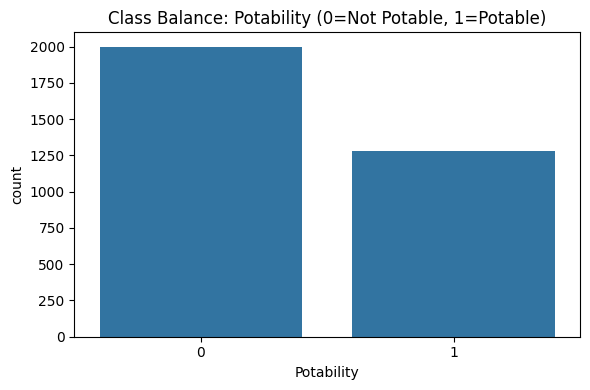

In [5]:
plt.figure(figsize=(6,4))
sns.countplot(x=df[target_col])
plt.title('Class Balance: Potability (0=Not Potable, 1=Potable)')
plt.tight_layout()
plt.show()

### 3.2 Feature distributions

<Figure size 1400x1000 with 0 Axes>

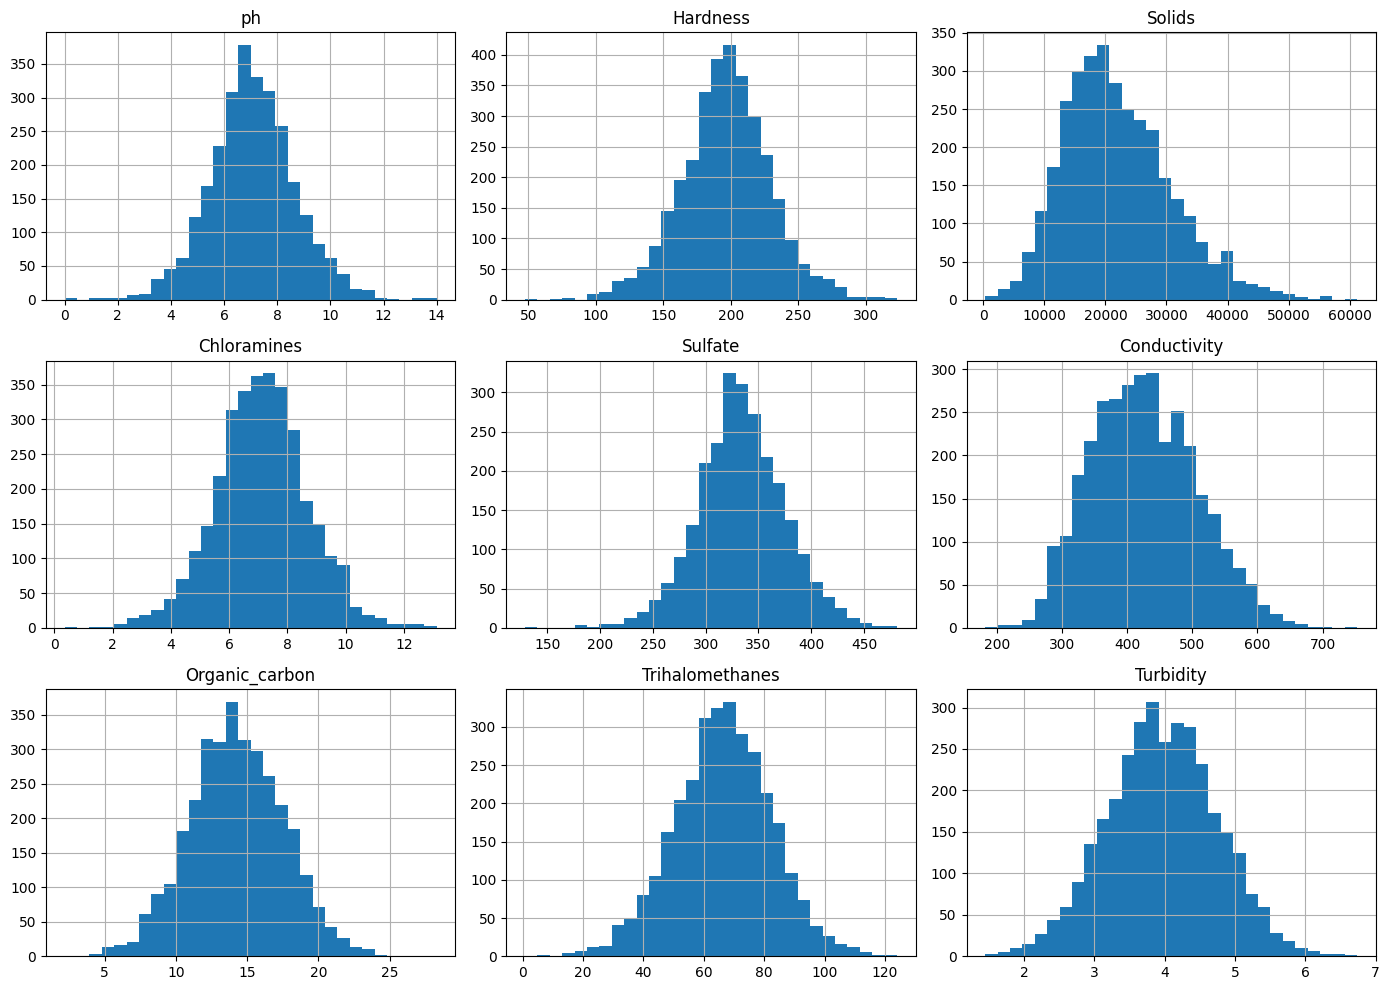

In [6]:
plt.figure(figsize=(14,10))
df[feature_cols].hist(bins=30, figsize=(14,10))
plt.tight_layout()
plt.show()

### 3.3 Correlation heatmap

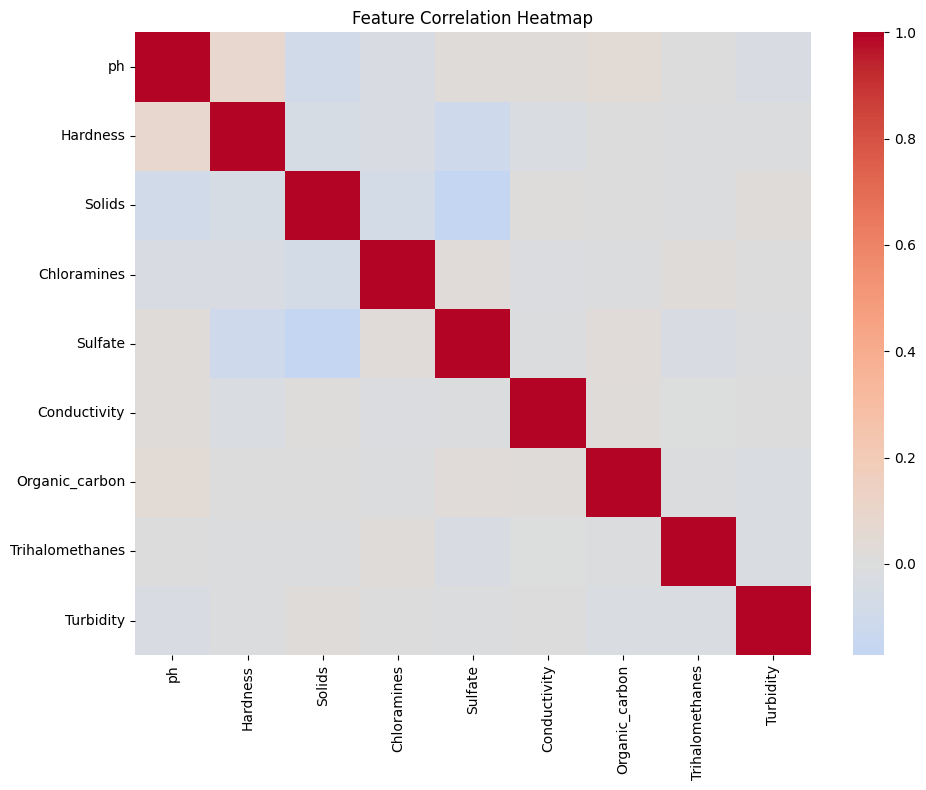

In [7]:
plt.figure(figsize=(10,8))
corr = df[feature_cols].corr()
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

## 4) Feature engineering
Lightweight engineered features (only when source columns exist):
- log1p transforms for skewed positive features
- a simple interaction feature for Conductivity and Hardness

In [8]:
X_fe = X.copy()

for col in ['Solids', 'Organic_carbon', 'Trihalomethanes', 'Turbidity']:
    if col in X_fe.columns:
        X_fe[col + '_log1p'] = np.log1p(X_fe[col].clip(lower=0))

if 'Conductivity' in X_fe.columns and 'Hardness' in X_fe.columns:
    X_fe['Conductivity_x_Hardness'] = X_fe['Conductivity'] * X_fe['Hardness']

feature_cols_fe = list(X_fe.columns)

X_train_fe, X_test_fe, y_train, y_test = train_test_split(
    X_fe, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print('Engineered feature count:', X_train_fe.shape[1])
X_train_fe.head()

Engineered feature count: 14


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Solids_log1p,Organic_carbon_log1p,Trihalomethanes_log1p,Turbidity_log1p,Conductivity_x_Hardness
2214,7.822492,208.636720,22308.821729,5.850328,408.123255,502.789396,16.135732,60.393982,3.835332,10.012782,2.841166,4.117312,1.575950,104900.330288
1634,6.037428,227.033994,12988.791229,8.476905,392.380529,306.386283,7.122391,41.190507,3.594217,9.471919,2.094625,3.742195,1.524798,69560.101358
2605,8.445219,228.522860,28966.569327,6.179855,NaN,361.705354,14.554220,60.612230,4.400706,10.273932,2.744332,4.120860,1.686530,82657.942053
114,6.745307,218.424637,21871.838700,7.165509,NaN,373.050102,16.826619,74.086080,3.902353,9.993001,2.880693,4.318635,1.589715,81483.333041
129,6.506488,202.285938,17087.076902,6.201983,326.662368,481.771934,16.535186,46.205748,3.548776,9.746136,2.864209,3.854516,1.514858,97455.687598


## 5) Model comparison
We compare multiple classification algorithms and evaluate them using the required metrics.

In [9]:
numeric_features = feature_cols_fe
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])

preprocess = ColumnTransformer(
    transformers=[('num', numeric_transformer, numeric_features)],
    remainder='drop'
)

models = {
    'LogisticRegression': LogisticRegression(max_iter=2000, class_weight='balanced'),
    'RandomForest': RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, class_weight='balanced'),
    'GradientBoosting': GradientBoostingClassifier(random_state=RANDOM_STATE),
    'SVC_RBF': SVC(kernel='rbf', probability=True, class_weight='balanced', random_state=RANDOM_STATE),
    'KNN': KNeighborsClassifier(n_neighbors=15),
    'NaiveBayes': GaussianNB(),
}

def evaluate_model(name, model, X_tr, X_te, y_tr, y_te):
    pipe = Pipeline(steps=[('preprocess', preprocess), ('model', model)])
    pipe.fit(X_tr, y_tr)
    y_pred = pipe.predict(X_te)

    if hasattr(pipe.named_steps['model'], 'predict_proba'):
        y_score = pipe.predict_proba(X_te)[:, 1]
    else:
        y_score = pipe.decision_function(X_te)

    metrics = {
        'model': name,
        'accuracy': accuracy_score(y_te, y_pred),
        'precision': precision_score(y_te, y_pred, zero_division=0),
        'recall': recall_score(y_te, y_pred, zero_division=0),
        'f1': f1_score(y_te, y_pred, zero_division=0),
        'roc_auc': roc_auc_score(y_te, y_score),
    }
    return pipe, metrics

results = []
best_roc_auc = -np.inf
best_model_name = None
best_pipe = None

for name, model in models.items():
    print('Training:', name)
    pipe, metrics = evaluate_model(name, model, X_train_fe, X_test_fe, y_train, y_test)
    results.append(metrics)
    print(metrics)

    if metrics['roc_auc'] > best_roc_auc:
        best_roc_auc = metrics['roc_auc']
        best_model_name = name
        best_pipe = pipe

results_df = pd.DataFrame(results).sort_values(by='roc_auc', ascending=False)
results_df

Training: LogisticRegression
{'model': 'LogisticRegression', 'accuracy': 0.5426829268292683, 'precision': 0.42142857142857143, 'recall': 0.4609375, 'f1': 0.44029850746268656, 'roc_auc': 0.5226464843749999}
Training: RandomForest
{'model': 'RandomForest', 'accuracy': 0.6295731707317073, 'precision': 0.5351351351351351, 'recall': 0.38671875, 'f1': 0.4489795918367347, 'roc_auc': 0.6395117187500001}
Training: GradientBoosting
{'model': 'GradientBoosting', 'accuracy': 0.6539634146341463, 'precision': 0.6494845360824743, 'recall': 0.24609375, 'f1': 0.35694050991501414, 'roc_auc': 0.6302929687500001}
Training: SVC_RBF
{'model': 'SVC_RBF', 'accuracy': 0.6234756097560976, 'precision': 0.5189873417721519, 'recall': 0.48046875, 'f1': 0.49898580121703856, 'roc_auc': 0.639072265625}
Training: KNN
{'model': 'KNN', 'accuracy': 0.6234756097560976, 'precision': 0.5405405405405406, 'recall': 0.234375, 'f1': 0.32697547683923706, 'roc_auc': 0.6032958984375001}
Training: NaiveBayes
{'model': 'NaiveBayes', 

,model,accuracy,precision,recall,f1,roc_auc
1,RandomForest,0.629573,0.535135,0.386719,0.448980,0.639512
3,SVC_RBF,0.623476,0.518987,0.480469,0.498986,0.639072
2,GradientBoosting,0.653963,0.649485,0.246094,0.356941,0.630293
4,KNN,0.623476,0.540541,0.234375,0.326975,0.603296
5,NaiveBayes,0.591463,0.447368,0.199219,0.275676,0.597656
0,LogisticRegression,0.542683,0.421429,0.460938,0.440299,0.522646


## 6) Final evaluation for the best model
- Confusion matrix
- ROC curve
- Permutation feature importance

Best model by ROC-AUC: RandomForest ROC-AUC: 0.6395117187500001


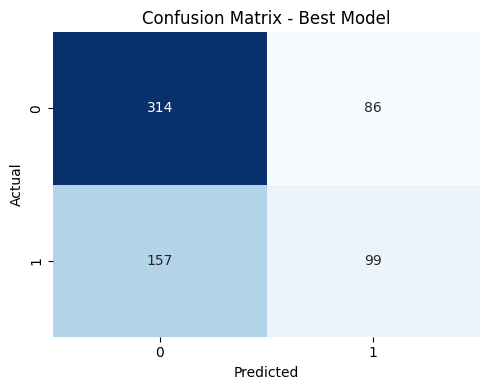

<Figure size 600x500 with 0 Axes>

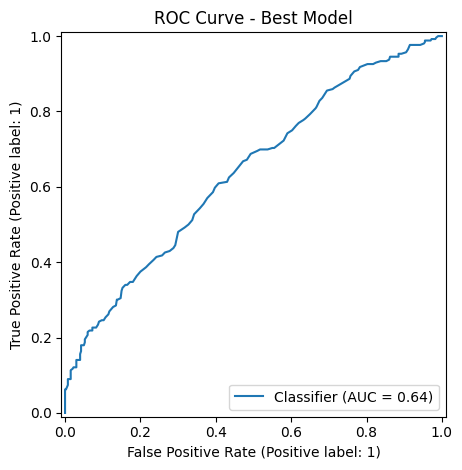

In [10]:
print('Best model by ROC-AUC:', best_model_name, 'ROC-AUC:', best_roc_auc)

y_pred = best_pipe.predict(X_test_fe)
if hasattr(best_pipe.named_steps['model'], 'predict_proba'):
    y_score = best_pipe.predict_proba(X_test_fe)[:, 1]
else:
    y_score = best_pipe.decision_function(X_test_fe)

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix - Best Model')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

plt.figure(figsize=(6,5))
RocCurveDisplay.from_predictions(y_test, y_score)
plt.title('ROC Curve - Best Model')
plt.tight_layout()
plt.show()


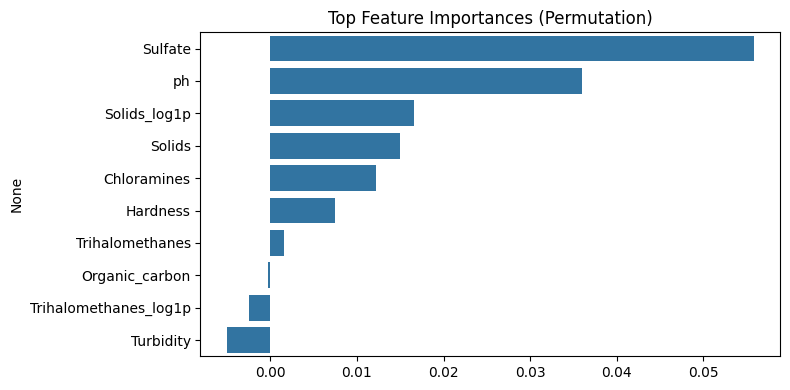

Sulfate                  0.055793
ph                       0.035976
Solids_log1p             0.016616
Solids                   0.014939
Chloramines              0.012195
Hardness                 0.007470
Trihalomethanes          0.001524
Organic_carbon          -0.000305
Trihalomethanes_log1p   -0.002439
Turbidity               -0.005030
dtype: float64

In [11]:
perm = permutation_importance(best_pipe, X_test_fe, y_test, n_repeats=10, random_state=RANDOM_STATE)
importances = pd.Series(perm.importances_mean, index=feature_cols_fe).sort_values(ascending=False)

top_n = min(10, len(importances))
plt.figure(figsize=(8,4))
sns.barplot(x=importances.head(top_n).values, y=importances.head(top_n).index, orient='h')
plt.title('Top Feature Importances (Permutation)')
plt.tight_layout()
plt.show()

importances.head(10)

## 7) Prediction examples
Use the trained best model to predict potability for sample inputs.

In [12]:
examples = X_test_fe.sample(n=5, random_state=RANDOM_STATE)
example_preds = best_pipe.predict(examples)

if hasattr(best_pipe.named_steps['model'], 'predict_proba'):
    example_proba = best_pipe.predict_proba(examples)[:, 1]
else:
    example_proba = None

print('Predictions (0=Not Potable, 1=Potable):')
print(example_preds)

if example_proba is not None:
    print('Potability probability for class=1:')
    print(np.round(example_proba, 4))

examples.assign(Predicted_Potability=example_preds).head(10)

Predictions (0=Not Potable, 1=Potable):
[0 1 0 0 0]
Potability probability for class=1:
[0.4767 0.6067 0.47   0.4067 0.3767]


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Solids_log1p,Organic_carbon_log1p,Trihalomethanes_log1p,Turbidity_log1p,Conductivity_x_Hardness,Predicted_Potability
2295,NaN,172.111514,26595.373543,8.232252,NaN,348.843576,7.877739,93.302816,3.550311,10.188530,2.183547,4.546511,1.515196,60039.995925,0
632,NaN,181.374651,14579.822073,5.435058,NaN,308.792515,9.545092,60.214647,4.161749,9.587462,2.355661,4.114386,1.641276,56007.134664,1
2243,6.014540,205.482940,23268.243081,9.035769,283.340368,371.403475,16.863668,73.017793,2.686069,10.054888,2.882769,4.304306,1.304561,76317.077917,0
2869,7.171224,199.160175,13163.031278,5.762522,351.278134,436.602436,19.103152,52.577451,2.209092,9.485243,3.000877,3.981128,1.165988,86953.817685,0
3113,7.734569,230.919506,21776.594455,6.908591,NaN,395.114961,15.033557,92.697369,3.821456,9.988637,2.774684,4.540070,1.573076,91239.751608,0
